In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

### 1. Ответы на вопросы

1. Выведите формулу для ELBO и объясните, почему эта функция потерь используется для обучения вариационного автокодировщика.

ELBO = Eq(z|x)[log p(x|z)] - KL(q(z|x) ∥ p(z))

ELBO (Evidence Lower Bound) - это функция потерь, используемая для обучения вариационного автокодировщика (VAE). Она состоит из двух частей:
- Eq(z|x)[log p(x|z)] - это ожидаемое значение логарифма вероятности восстановления входных данных x из латентного представления z. Эта часть поощряет модель генерировать данные, которые максимально похожи на входные данные.
- KL(q(z∣x)∥p(z)) - это дивергенция Кульбака-Лейблера между апостериорным распределением q(z|x) и априорным распределением p(z). Эта часть поощряет модель генерировать латентные представления, которые соответствуют априорному распределению, что помогает избежать переобучения и обеспечивает более гладкое латентное пространство.


2. Объясните, какая функция потерь используется для генератора и дискриминатора в генеративно-состязательной сети.

В генеративно-состязательной сети (GAN) используются следующие функции потерь для генератора и дискриминатора:

Для дискриминатора:
- L_D = -E[log D(x)] - E[log(1 - D(G(z)))]
Дискриминатор стремится максимизировать вероятность правильной классификации реальных данных (x) и минимизировать вероятность неправильной классификации сгенерированных данных (G(z)).

Для генератора:
- L_G = -E[log D(G(z))]
Генератор стремится минимизировать вероятность того, что дискриминатор правильно классифицирует сгенерированные данные как фейковые, то есть пытается "обмануть" дискриминатор.



### 2. Реализация вариационного автокодировщика

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(28 * 28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 28 * 28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


vae = VAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

In [14]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (BCE)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [15]:
epochs = 10

vae.train()
for epoch in range(epochs):
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 28 * 28).to(device)

        optimizer.zero_grad()

        recon_x, mu, logvar = vae(x)
        loss = loss_function(recon_x, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

Epoch 1, Loss: 191.5554
Epoch 2, Loss: 167.7875
Epoch 3, Loss: 163.0747
Epoch 4, Loss: 160.4579
Epoch 5, Loss: 158.5433
Epoch 6, Loss: 157.0541
Epoch 7, Loss: 155.7345
Epoch 8, Loss: 154.7384
Epoch 9, Loss: 153.9266
Epoch 10, Loss: 153.1648


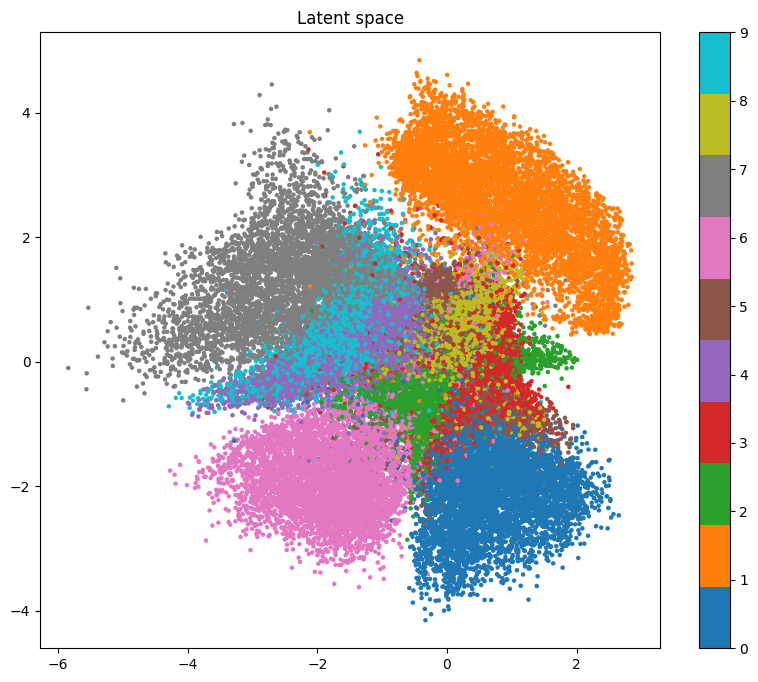

In [51]:
def plot_latent_space(model, train_loader):
    model.eval()

    z_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in train_loader:
            x = x.view(-1, 28 * 28).to(device)
            mu, logvar = model.encode(x)
            z = mu

            z_list.append(z.cpu())
            labels_list.append(y)

    z = torch.cat(z_list)
    labels = torch.cat(labels_list)

    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10', s=5)
    plt.colorbar(scatter)

    plt.title("Latent space")
    plt.show()


plot_latent_space(vae, train_loader)

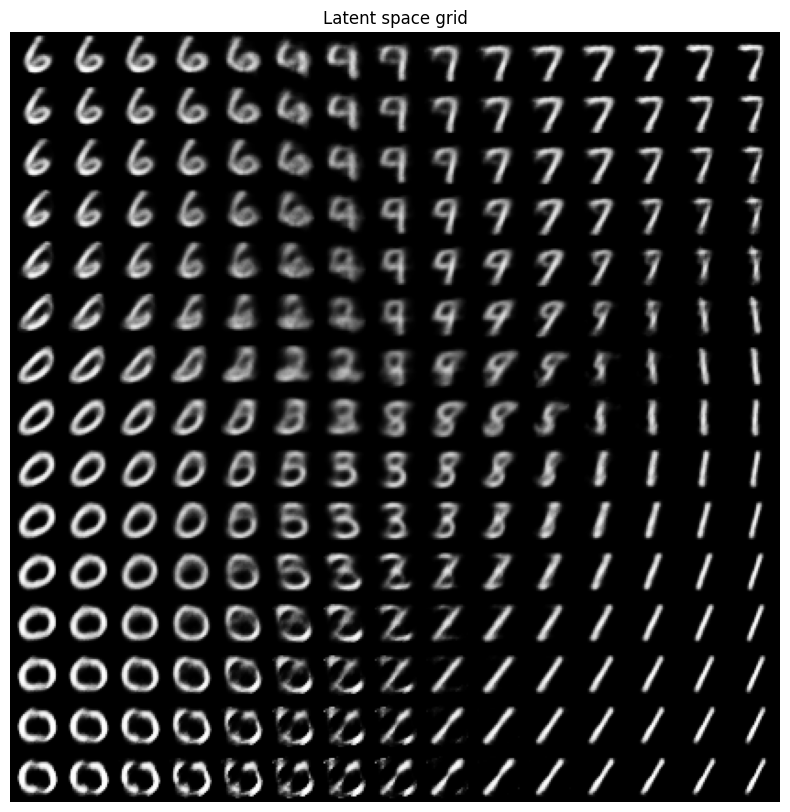

In [48]:
def plot_grid(model, grid_size=15, range_=3):
    model.eval()

    z1 = np.linspace(-range_, range_, grid_size)
    z2 = np.linspace(-range_, range_, grid_size)

    grid = np.zeros((28 * grid_size, 28 * grid_size))

    with torch.no_grad():
        for i, zi in enumerate(z1):
            for j, zj in enumerate(z2):
                z = torch.tensor([[zi, zj]], dtype=torch.float32).to(device)

                recon = model.decode(z)
                img = recon.view(28, 28).cpu().numpy()

                grid[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img

    plt.figure(figsize=(10, 8))
    plt.imshow(grid, cmap='gray')
    plt.axis('off')
    plt.title("Latent space grid")
    plt.show()


plot_grid(vae)

### 3. Реализация вариационного автокодировщика с учителем

In [66]:
class VAE_Teacher(nn.Module):
    def __init__(self, latent_dim=1):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc2 = nn.Linear(latent_dim + 10, 400)
        self.fc3 = nn.Linear(400, 28 * 28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        x = torch.cat([z, y], dim=1)
        h = F.relu(self.fc2(x))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x, y):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar


vae_t = VAE_Teacher(latent_dim=1).to(device)
optimizer = torch.optim.Adam(vae_t.parameters(), lr=1e-3)

epochs = 10

vae_t.train()
for epoch in range(epochs):
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 28 * 28).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        optimizer.zero_grad()

        recon_x, mu, logvar = vae_t(x, y)
        loss = loss_function(recon_x, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

Epoch 1, Loss: 185.0224
Epoch 2, Loss: 156.4337
Epoch 3, Loss: 152.2330
Epoch 4, Loss: 150.5494
Epoch 5, Loss: 149.5355
Epoch 6, Loss: 148.8672
Epoch 7, Loss: 148.3776
Epoch 8, Loss: 147.9865
Epoch 9, Loss: 147.6672
Epoch 10, Loss: 147.4084


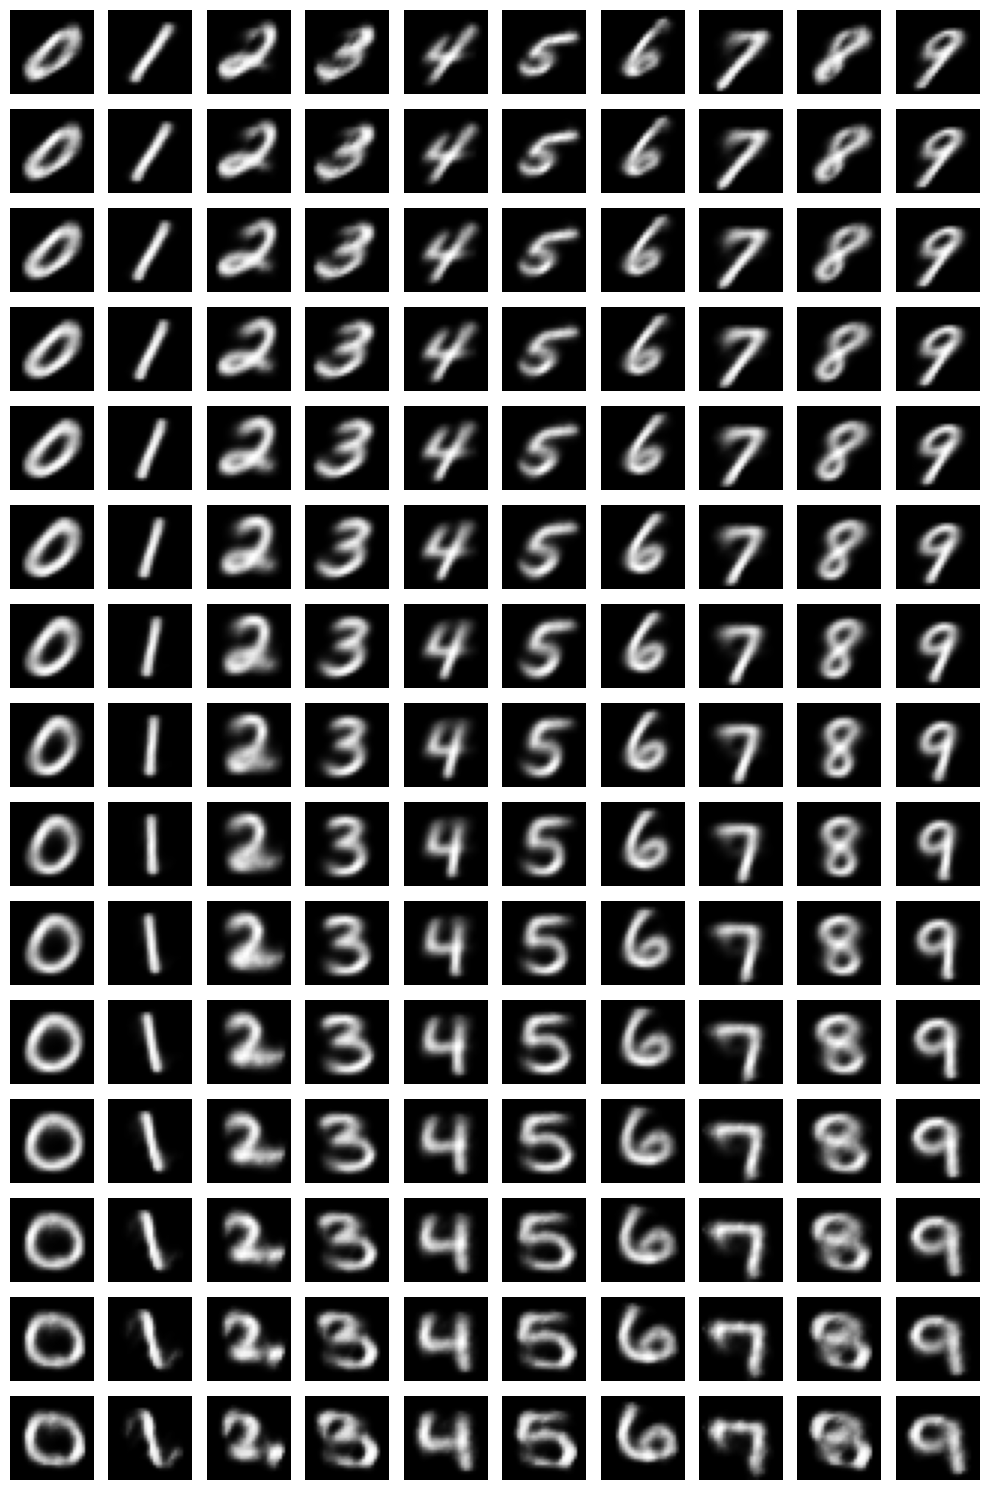

In [74]:
vae_t.eval()

images = []
z_vals = np.linspace(-3, 3, 15)
digits = list(range(10))

with torch.no_grad():
    for z in z_vals:
        row = []

        z_tensor = torch.tensor([[z]], dtype=torch.float32).to(device)

        for digit in digits:
            y = torch.tensor([digit])
            y = F.one_hot(y, num_classes=10).float().to(device)

            img = vae_t.decode(z_tensor, y)
            img = img.cpu().view(28, 28).numpy()

            row.append(img)

        images.append(row)

fig, axes = plt.subplots(15, 10, figsize=(10, 15))

for i in range(15):
    for j in range(10):
        axes[i, j].imshow(images[i][j], cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

### 4. Реализация генеративно-состязательной сети

In [205]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


class Generator(nn.Module):
    def __init__(self, z_dim=2, img_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)


z_dim = 2
img_dim = 784

G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

losses_G = []
losses_D = []


def train_model(epochs):
    for epoch in range(epochs):
        epoch_g = []
        epoch_d = []

        for real, _ in train_loader:
            real = real.view(real.size(0), -1).to(device)
            batch_size = real.size(0)

            # Обновляем дискриминатор
            z = torch.randn(batch_size, z_dim, device=device)
            fake = G(z)

            real_labels = torch.ones(batch_size, 1, device=device) * 0.9  # Сглаживание меток для реальных данных
            fake_labels = torch.zeros(batch_size, 1, device=device)

            D_real = D(real)
            D_fake = D(fake.detach())

            loss_D = (
                    criterion(D_real, real_labels) +
                    criterion(D_fake, fake_labels)
            )

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Обновляем генератор
            z = torch.randn(batch_size, z_dim, device=device)
            fake = G(z)

            loss_G = criterion(D(fake), real_labels)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_g.append(loss_G.item())
            epoch_d.append(loss_D.item())

        losses_G.append(sum(epoch_g) / len(epoch_g))
        losses_D.append(sum(epoch_d) / len(epoch_d))

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss D: {losses_D[-1]:.4f} "
            f"Loss G: {losses_G[-1]:.4f}"
        )

        if (epoch + 1) % 5 == 0:
            visualize_latent_space(G)


def plot_losses(losses_G, losses_D):
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label="Generator")
    plt.plot(losses_D, label="Discriminator")
    plt.legend()
    plt.show()


def visualize_latent_space(G, grid_size=15, range_=2):
    images = []
    grid_x = np.linspace(-range_, range_, grid_size)
    grid_y = np.linspace(-range_, range_, grid_size)

    with torch.no_grad():
        G.eval()
        for i, y in enumerate(grid_y):
            row = []
            for x in grid_x:
                z = torch.tensor([[x, y]], dtype=torch.float32).to(device)
                img = G(z)
                img = img.cpu().view(28, 28).numpy()
                img = (img * 0.5) + 0.5
                row.append(img)
            images.append(row)

    fig, axes = plt.subplots(15, 15, figsize=(12, 12))

    for i in range(15):
        for j in range(15):
            axes[i, j].imshow(images[i][j], cmap='gray')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

Device: cuda


Epoch [1/20] Loss D: 0.9718 Loss G: 1.3496
Epoch [2/20] Loss D: 0.7541 Loss G: 2.3370
Epoch [3/20] Loss D: 0.6939 Loss G: 2.8489
Epoch [4/20] Loss D: 0.6609 Loss G: 2.9341
Epoch [5/20] Loss D: 0.6815 Loss G: 2.8500


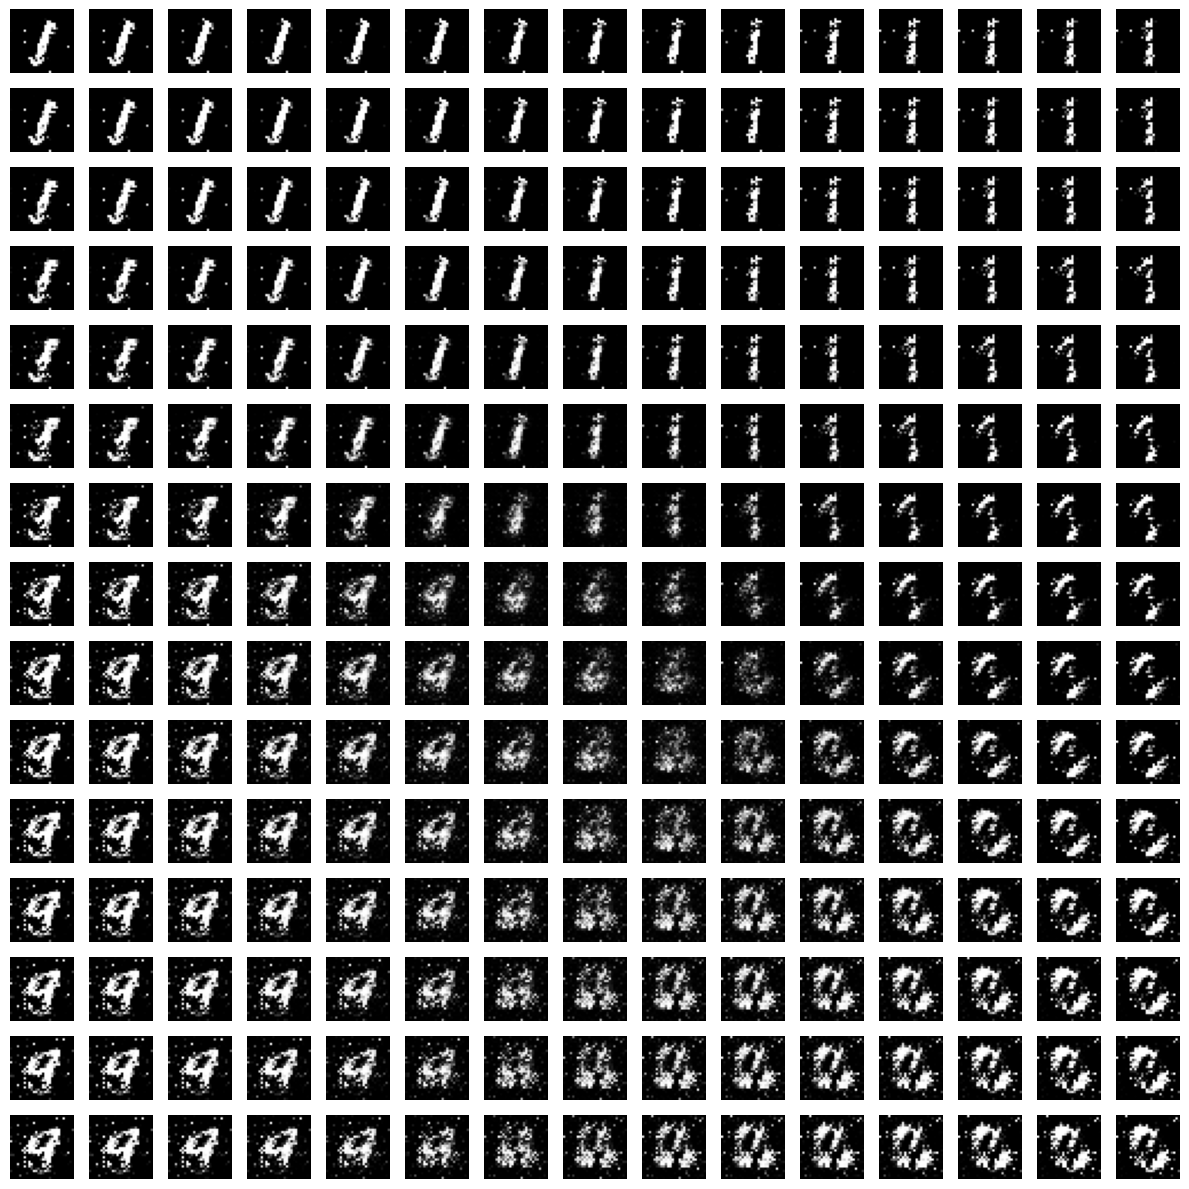

Epoch [6/20] Loss D: 0.6779 Loss G: 2.8175
Epoch [7/20] Loss D: 0.6541 Loss G: 2.8951
Epoch [8/20] Loss D: 0.6422 Loss G: 3.0224
Epoch [9/20] Loss D: 0.6161 Loss G: 3.0314
Epoch [10/20] Loss D: 0.6583 Loss G: 3.0596


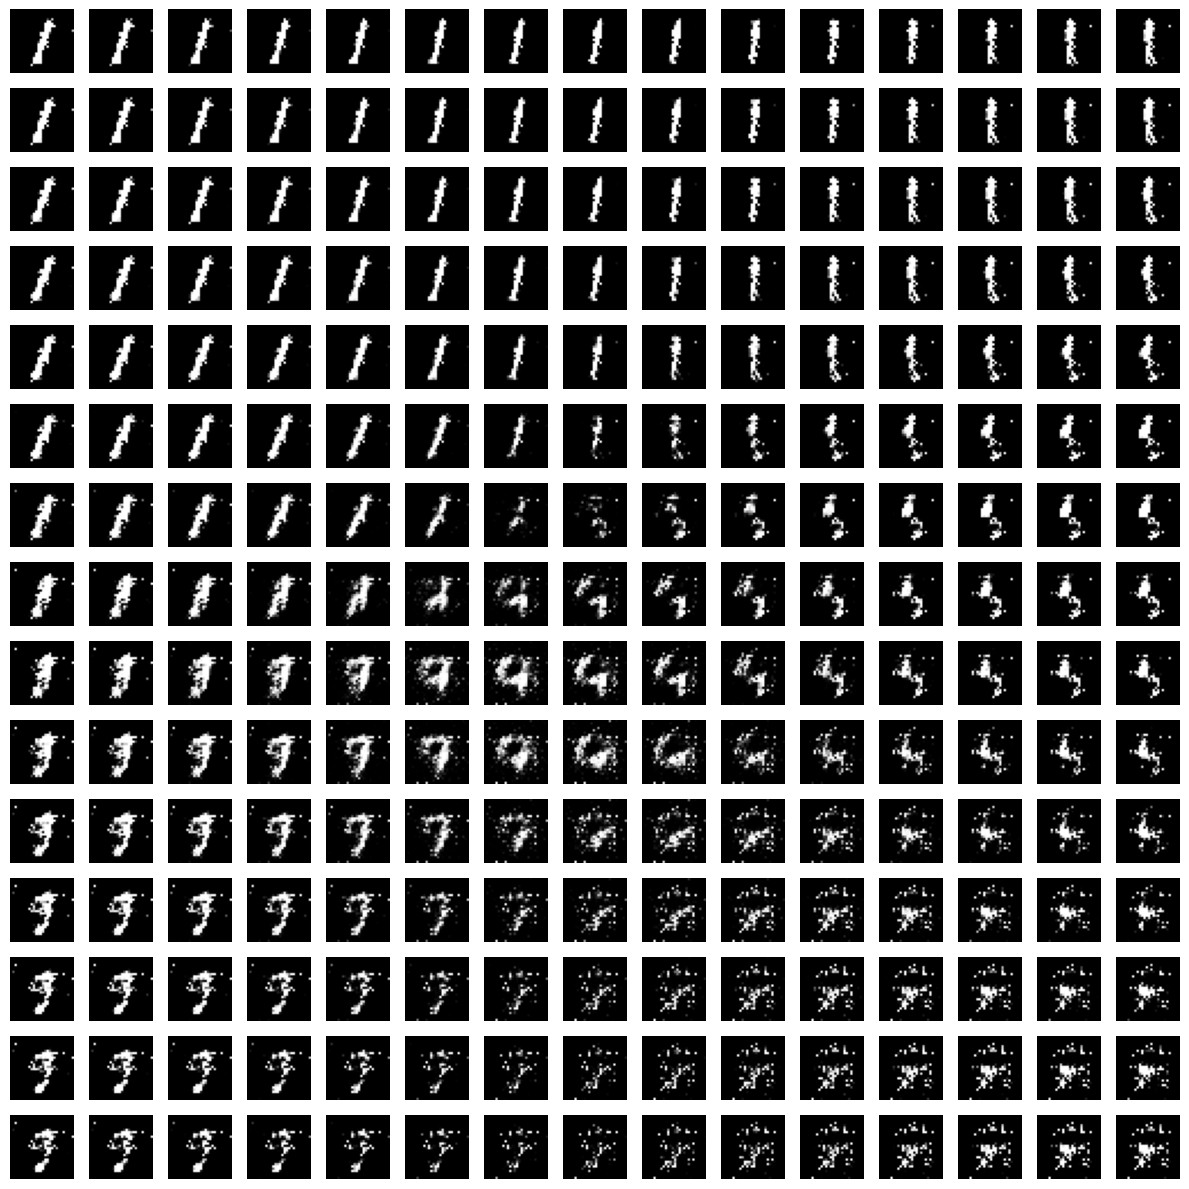

Epoch [11/20] Loss D: 0.6886 Loss G: 2.7433
Epoch [12/20] Loss D: 0.7081 Loss G: 2.6423
Epoch [13/20] Loss D: 0.7508 Loss G: 2.4164
Epoch [14/20] Loss D: 0.7630 Loss G: 2.3804
Epoch [15/20] Loss D: 0.7825 Loss G: 2.2907


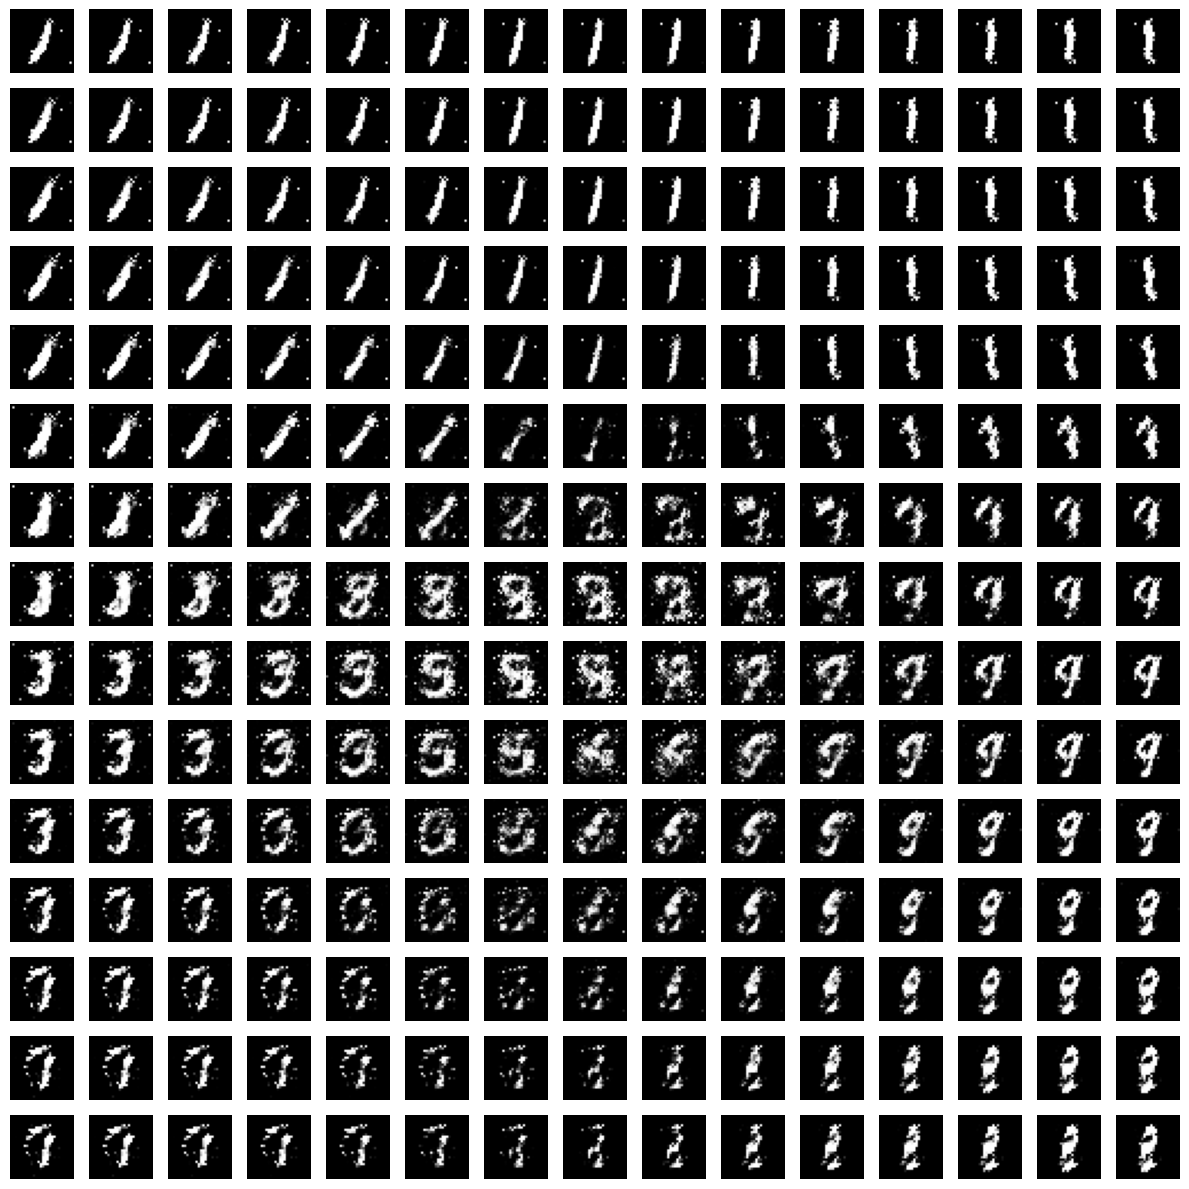

Epoch [16/20] Loss D: 0.8219 Loss G: 2.1724
Epoch [17/20] Loss D: 0.7952 Loss G: 2.2070
Epoch [18/20] Loss D: 0.7914 Loss G: 2.1761
Epoch [19/20] Loss D: 0.8153 Loss G: 2.1150
Epoch [20/20] Loss D: 0.8177 Loss G: 2.1290


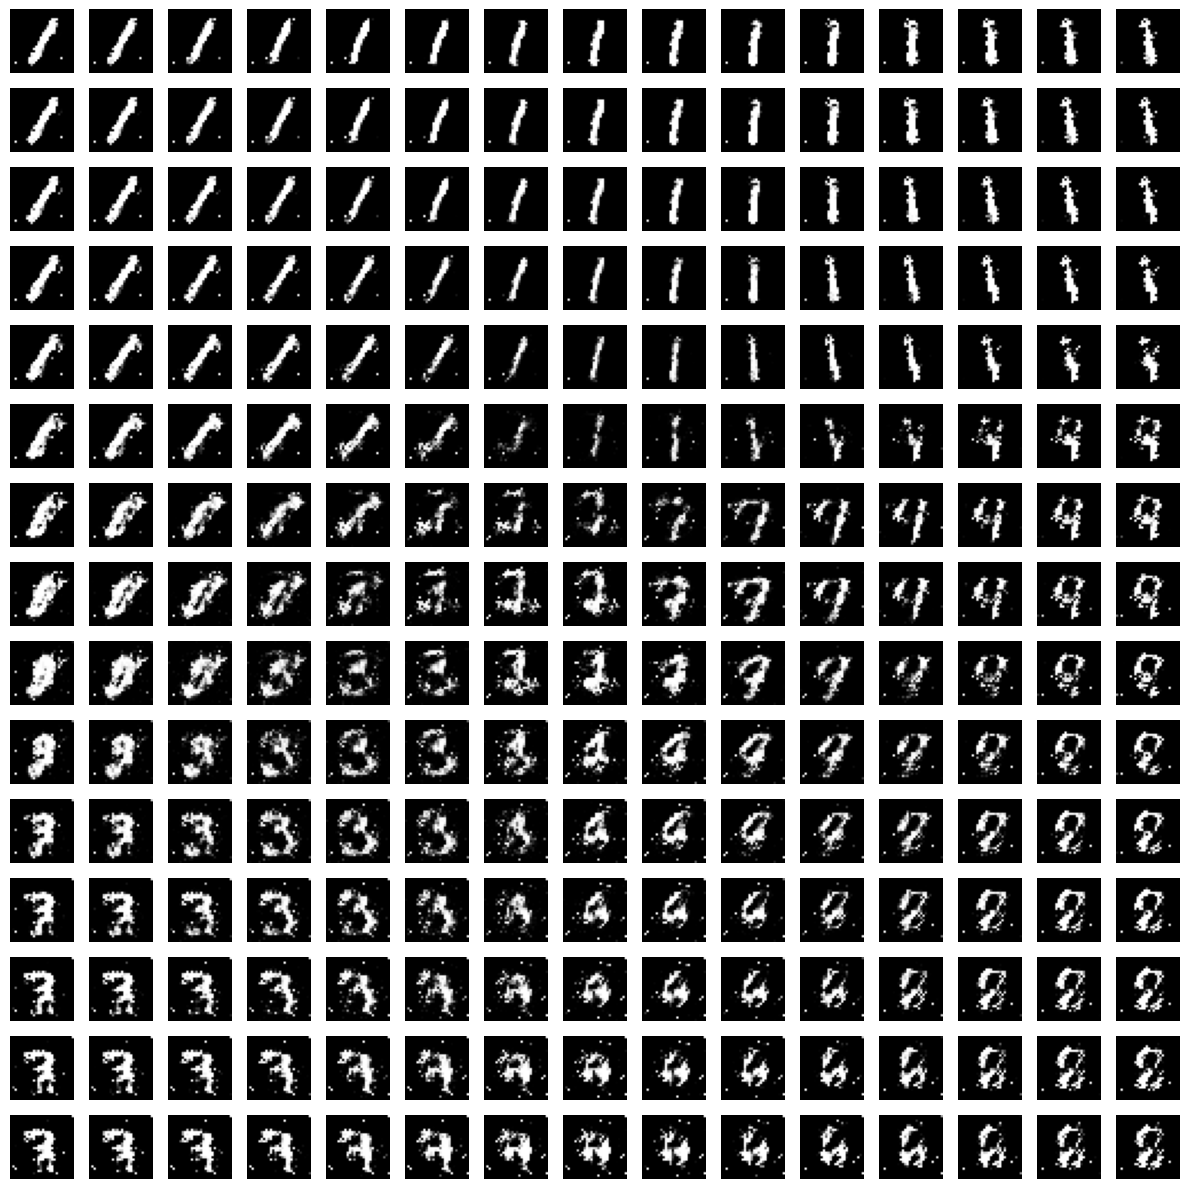

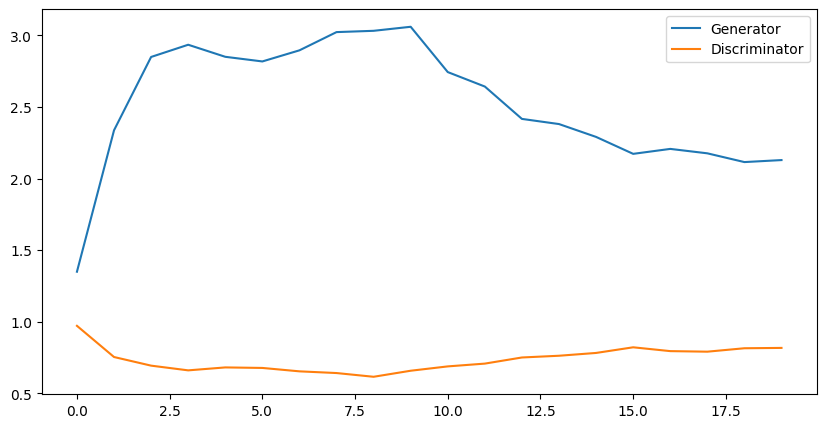

In [206]:
train_model(epochs=20)
plot_losses(losses_G, losses_D)

### 5. Реверсивная нейронная сеть

In [231]:
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        # Инвертируем градиент: умножаем на -alpha
        return grad_output.neg() * ctx.alpha, None


def revgrad(x, alpha=0.01):
    return GradientReversal.apply(x, alpha)

In [269]:
z_dim = 2
img_dim = 784

G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

# opt = torch.optim.Adam(
#     list(G.parameters()) + list(D.parameters()),
#     lr=2e-4,
#     betas=(0.5, 0.999)
# )

opt = torch.optim.Adam([
    # Параметры Генератора обучаются со стандартной скоростью
    {'params': G.parameters(), 'lr': 2e-4}, 
    # Параметры Дискриминатора обучаются значительно медленнее
    {'params': D.parameters(), 'lr': 5e-4}  
], betas=(0.5, 0.999))


def train_model_grl(epochs, alpha=0.01):
    for epoch in range(epochs):
        epoch_loss = 0.0

        for real, _ in train_loader:
            batch_size = real.size(0)
            real = real.view(batch_size, -1).to(device)

            # 1. Генерируем фейки
            z = torch.randn(batch_size, z_dim, device=device)
            fake = G(z)

            # Проход для реальных (без GRL)
            real_out = D(real)
            # Проход для фейковых (GRL)
            fake_out = D(revgrad(fake, alpha))

            # 3. Считаем потери для обеих сетей вместе
            loss_real = criterion(real_out, torch.ones_like(real_out) * 0.9)  # Сглаживание
            loss_fake = criterion(fake_out, torch.zeros_like(fake_out))

            loss = loss_real + loss_fake

            # 4. Один обратный шаг для обеих сетей
            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{epochs}] Total Loss: {epoch_loss / len(train_loader):.4f}")

        if (epoch + 1) % 5 == 0:
            visualize_latent_space(G)

Epoch [1/10] Total Loss: 0.8878
Epoch [2/10] Total Loss: 0.5273
Epoch [3/10] Total Loss: 0.5268
Epoch [4/10] Total Loss: 0.5119
Epoch [5/10] Total Loss: 0.4905


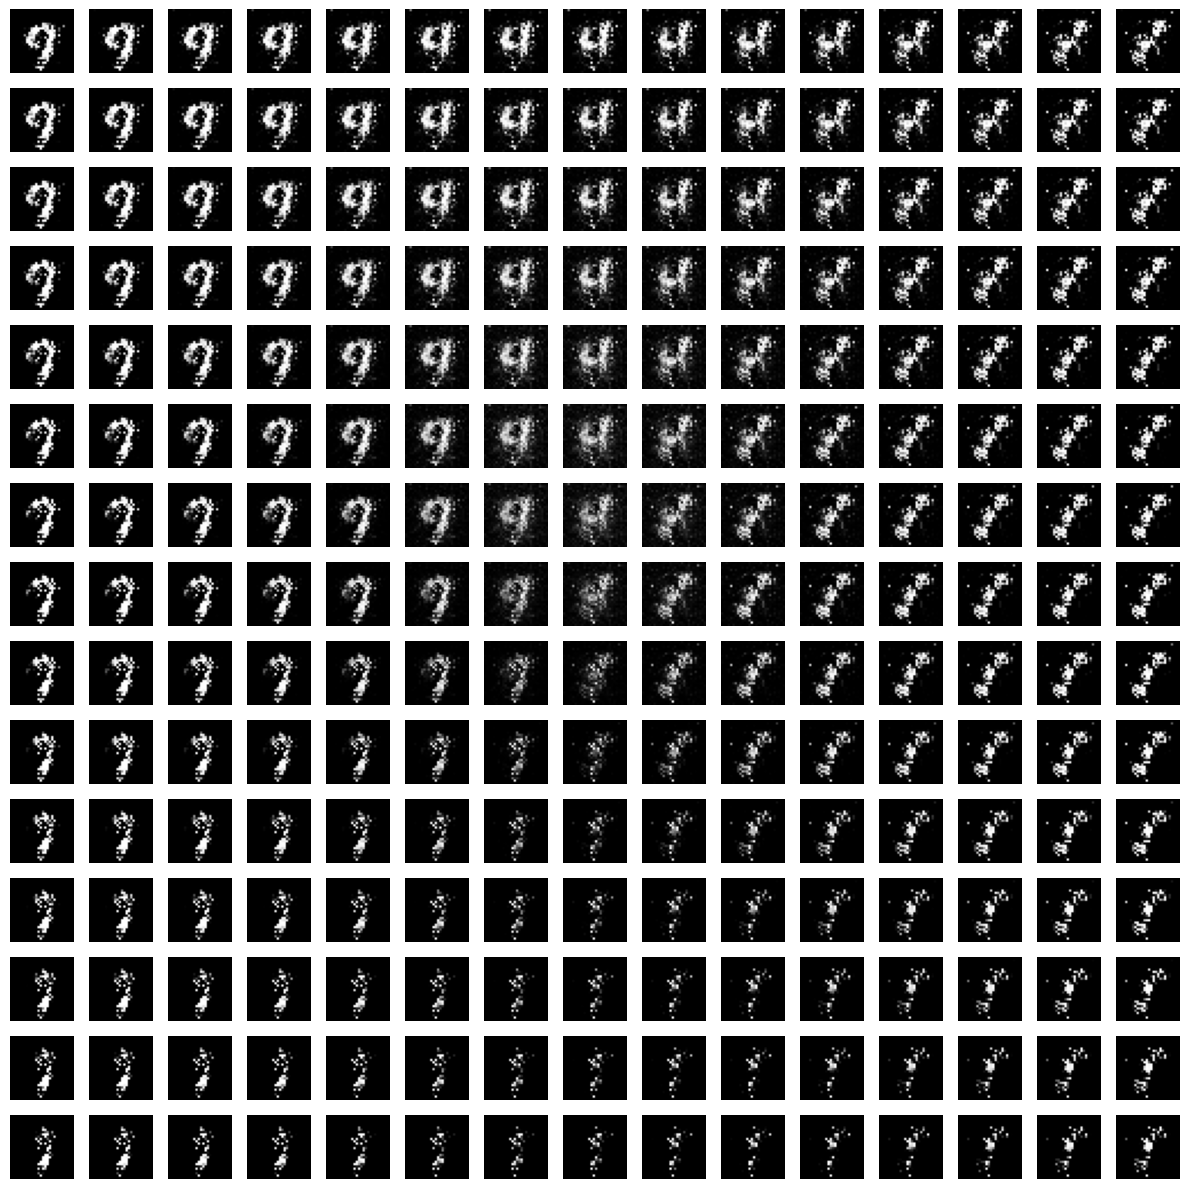

Epoch [6/10] Total Loss: 0.4526
Epoch [7/10] Total Loss: 0.5041
Epoch [8/10] Total Loss: 0.5045
Epoch [9/10] Total Loss: 0.4100
Epoch [10/10] Total Loss: 0.4435


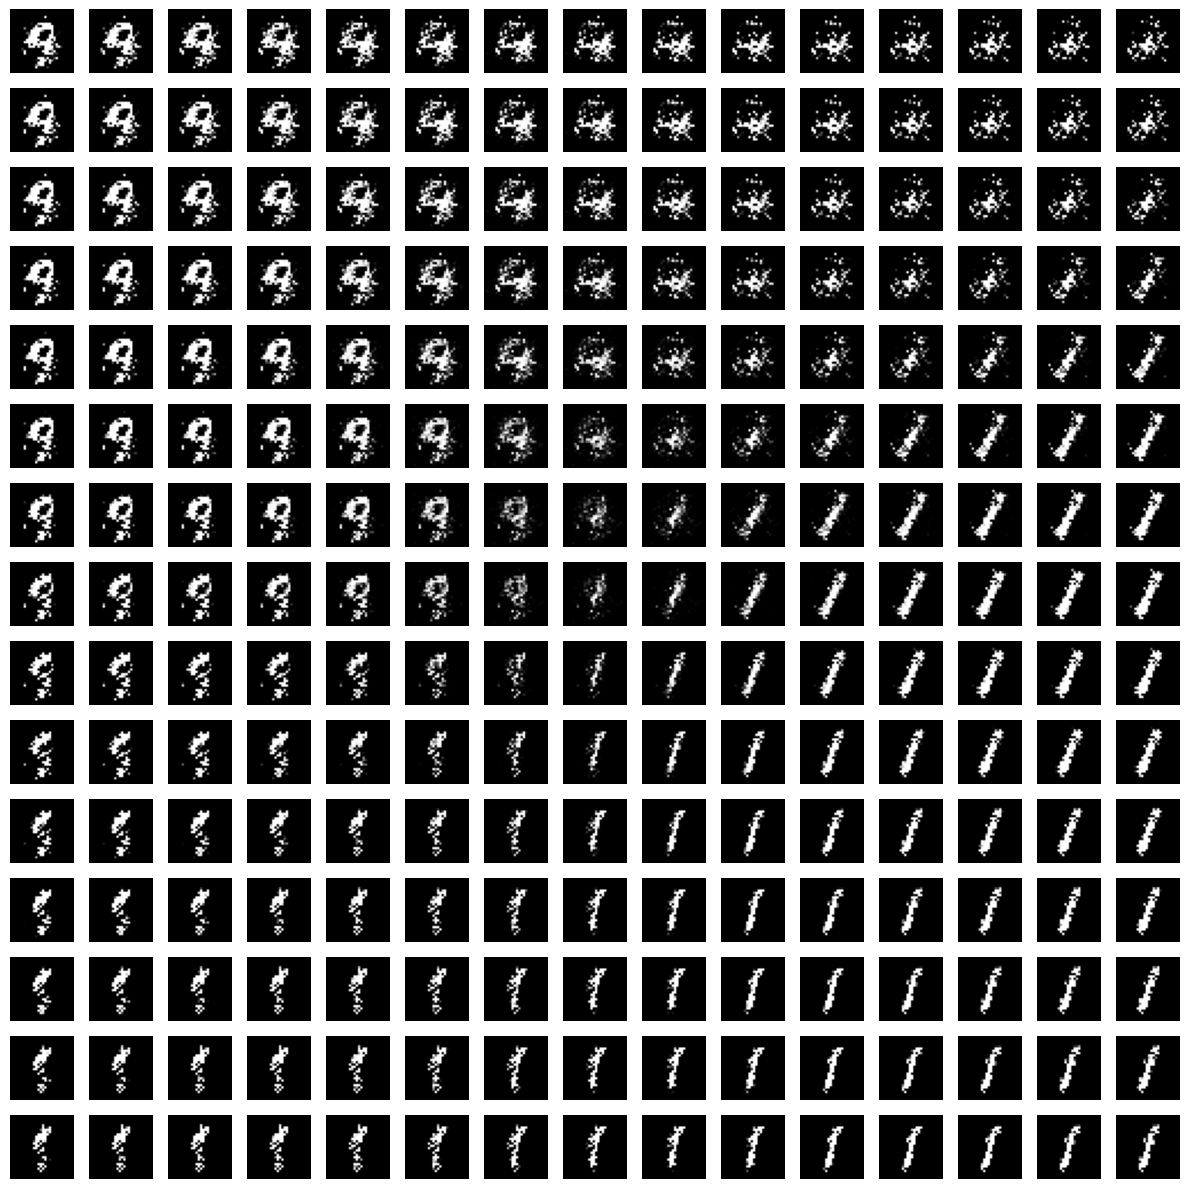

In [270]:
train_model_grl(epochs=10, alpha=0.01)

### 6. Управляемая генеративно-состязательная сеть

In [141]:
class ConditionalGenerator(nn.Module):
    def __init__(self, z_dim=10, num_classes=10, img_dim=784):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, img_dim),
            nn.Tanh()
        )

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        return self.model(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=10, img_dim=784):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(img_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x, labels):
        c = self.label_emb(labels)
        x = torch.cat([x, c], dim=1)
        return self.model(x)


In [225]:
def visualize_fixed_z(G, z_dim=10):
    G.eval()

    z = torch.randn(1, z_dim).repeat(10, 1).to(device)
    labels = torch.arange(0, 10).to(device)

    with torch.no_grad():
        imgs = G(z, labels).cpu().view(-1, 28, 28)

    fig, axes = plt.subplots(1, 10, figsize=(15, 2))

    for i in range(10):
        axes[i].imshow(imgs[i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(str(i))

    plt.show()


z_dim = 10
img_dim = 784

G = ConditionalGenerator(z_dim, img_dim).to(device)
D = ConditionalDiscriminator(img_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))


def train_model_cgrl(epochs):
    epoch_g = []
    epoch_d = []

    for epoch in range(epochs):
        for real, labels in train_loader:
            real = real.view(real.size(0), -1).to(device)
            labels = labels.to(device)
            batch_size = real.size(0)

            # Геренируем фейковые изображения
            z = torch.randn(batch_size, z_dim, device=device)
            fake_labels = torch.randint(0, 10, (batch_size,), device=device)

            fake = G(z, fake_labels)

            # Дискриминатор
            real_out = D(real, labels)
            fake_out = D(fake.detach(), fake_labels)

            loss_D = (
                    criterion(real_out, torch.ones(batch_size, 1, device=device) * 0.9) +
                    criterion(fake_out, torch.zeros(batch_size, 1, device=device))
            )

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # Генератор
            z = torch.randn(batch_size, z_dim, device=device)
            gen_labels = torch.randint(0, 10, (batch_size,), device=device)

            fake = G(z, gen_labels)

            loss_G = criterion(D(fake, gen_labels), torch.ones(batch_size, 1, device=device))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_g.append(loss_G.item())
            epoch_d.append(loss_D.item())

        losses_G.append(sum(epoch_g) / len(epoch_g))
        losses_D.append(sum(epoch_d) / len(epoch_d))

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss D: {losses_D[-1]:.4f} "
            f"Loss G: {losses_G[-1]:.4f}"
        )

        if (epoch + 1) % 5 == 0:
            # visualize_latent_space(G)
            visualize_fixed_z(G)

Epoch [1/20] Loss D: 1.1254 Loss G: 1.0784
Epoch [2/20] Loss D: 1.0411 Loss G: 1.3405
Epoch [3/20] Loss D: 1.0159 Loss G: 1.4336
Epoch [4/20] Loss D: 1.0046 Loss G: 1.4895
Epoch [5/20] Loss D: 1.0000 Loss G: 1.5151


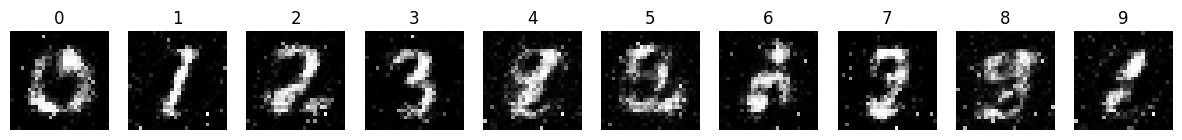

Epoch [6/20] Loss D: 1.0049 Loss G: 1.5280
Epoch [7/20] Loss D: 1.0080 Loss G: 1.5381
Epoch [8/20] Loss D: 1.0099 Loss G: 1.5450
Epoch [9/20] Loss D: 1.0120 Loss G: 1.5468
Epoch [10/20] Loss D: 1.0136 Loss G: 1.5465


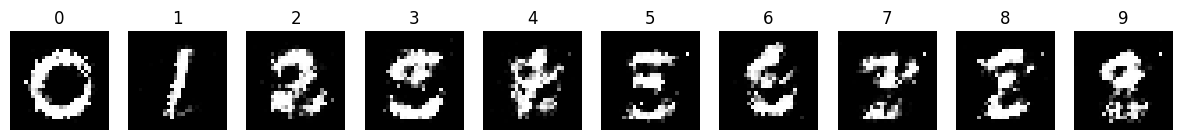

Epoch [11/20] Loss D: 1.0166 Loss G: 1.5442
Epoch [12/20] Loss D: 1.0214 Loss G: 1.5350
Epoch [13/20] Loss D: 1.0262 Loss G: 1.5248
Epoch [14/20] Loss D: 1.0340 Loss G: 1.5082
Epoch [15/20] Loss D: 1.0413 Loss G: 1.4911


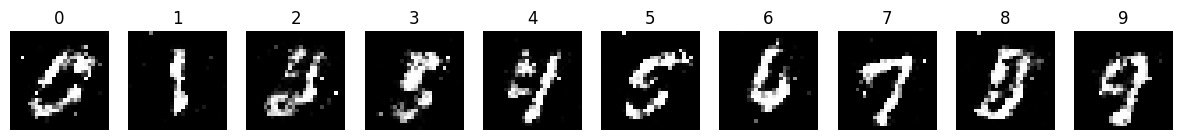

Epoch [16/20] Loss D: 1.0481 Loss G: 1.4757
Epoch [17/20] Loss D: 1.0551 Loss G: 1.4588
Epoch [18/20] Loss D: 1.0618 Loss G: 1.4432
Epoch [19/20] Loss D: 1.0684 Loss G: 1.4276
Epoch [20/20] Loss D: 1.0746 Loss G: 1.4135


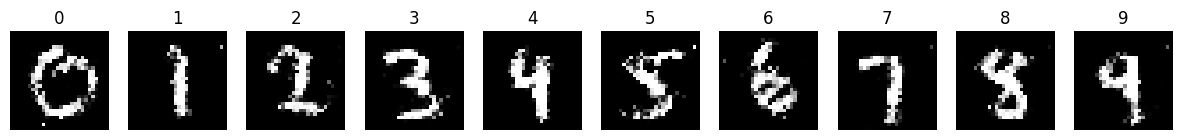

In [226]:
train_model_cgrl(epochs=20)